In [1]:
import os
from typing import cast

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import yaml

from tabletop_py.gaze.preprocess import (
    calculate_eyelink_speed,
    interpolate_markers,
    smooth_rolling,
    smooth_savgol,
)
from tabletop_py.gaze.visualize import (
    animate_2d_dots,
    animate_3d_dots,
    plot_eyelink_markers,
)

In [2]:
# session_dir = os.path.join(
#     os.environ["ROS_BAG_DIR"], "session_2025-08-12_15-19-30"
# )
session_dir = "/tabletop/bags/session_2025-08-22_02-22-51"
config_path = os.path.join(
    os.environ["TABLETOP_DIR"], "config", "gaze_estimation.yaml"
)
with open(config_path, "r") as f:
    config = yaml.safe_load(f)

eyelink_path = os.path.join(session_dir, "eyelink_sample.csv")
markers_path = os.path.join(session_dir, "markers.csv")

eyelink_df = pd.read_csv(eyelink_path, index_col=False)
markers_df = pd.read_csv(markers_path, index_col=False)

eyelink_freq = config["preprocess"]["eyelink_freq"]
markers_freq = config["preprocess"]["markers_freq"]
# orig_df = pd.read_csv(os.path.join(session_dir, "preprocessed.csv"), index_col=False)


Found 0 samples above 1000000 and 0 samples below 0 out of 2000 sample for orig_df[left_speed]
Found 0 samples above 1000000 and 0 samples below 0 out of 2000 sample for orig_df[right_speed]
Found 0 samples above 1000000 and 0 samples below 0 out of 2000 sample for smooth_df[left_speed]
Found 0 samples above 1000000 and 0 samples below 0 out of 2000 sample for smooth_df[right_speed]
Found 0 samples above 1000000 and 0 samples below 0 out of 1999 sample for savgol_df[left_speed]
Found 0 samples above 1000000 and 0 samples below 0 out of 1999 sample for savgol_df[right_speed]


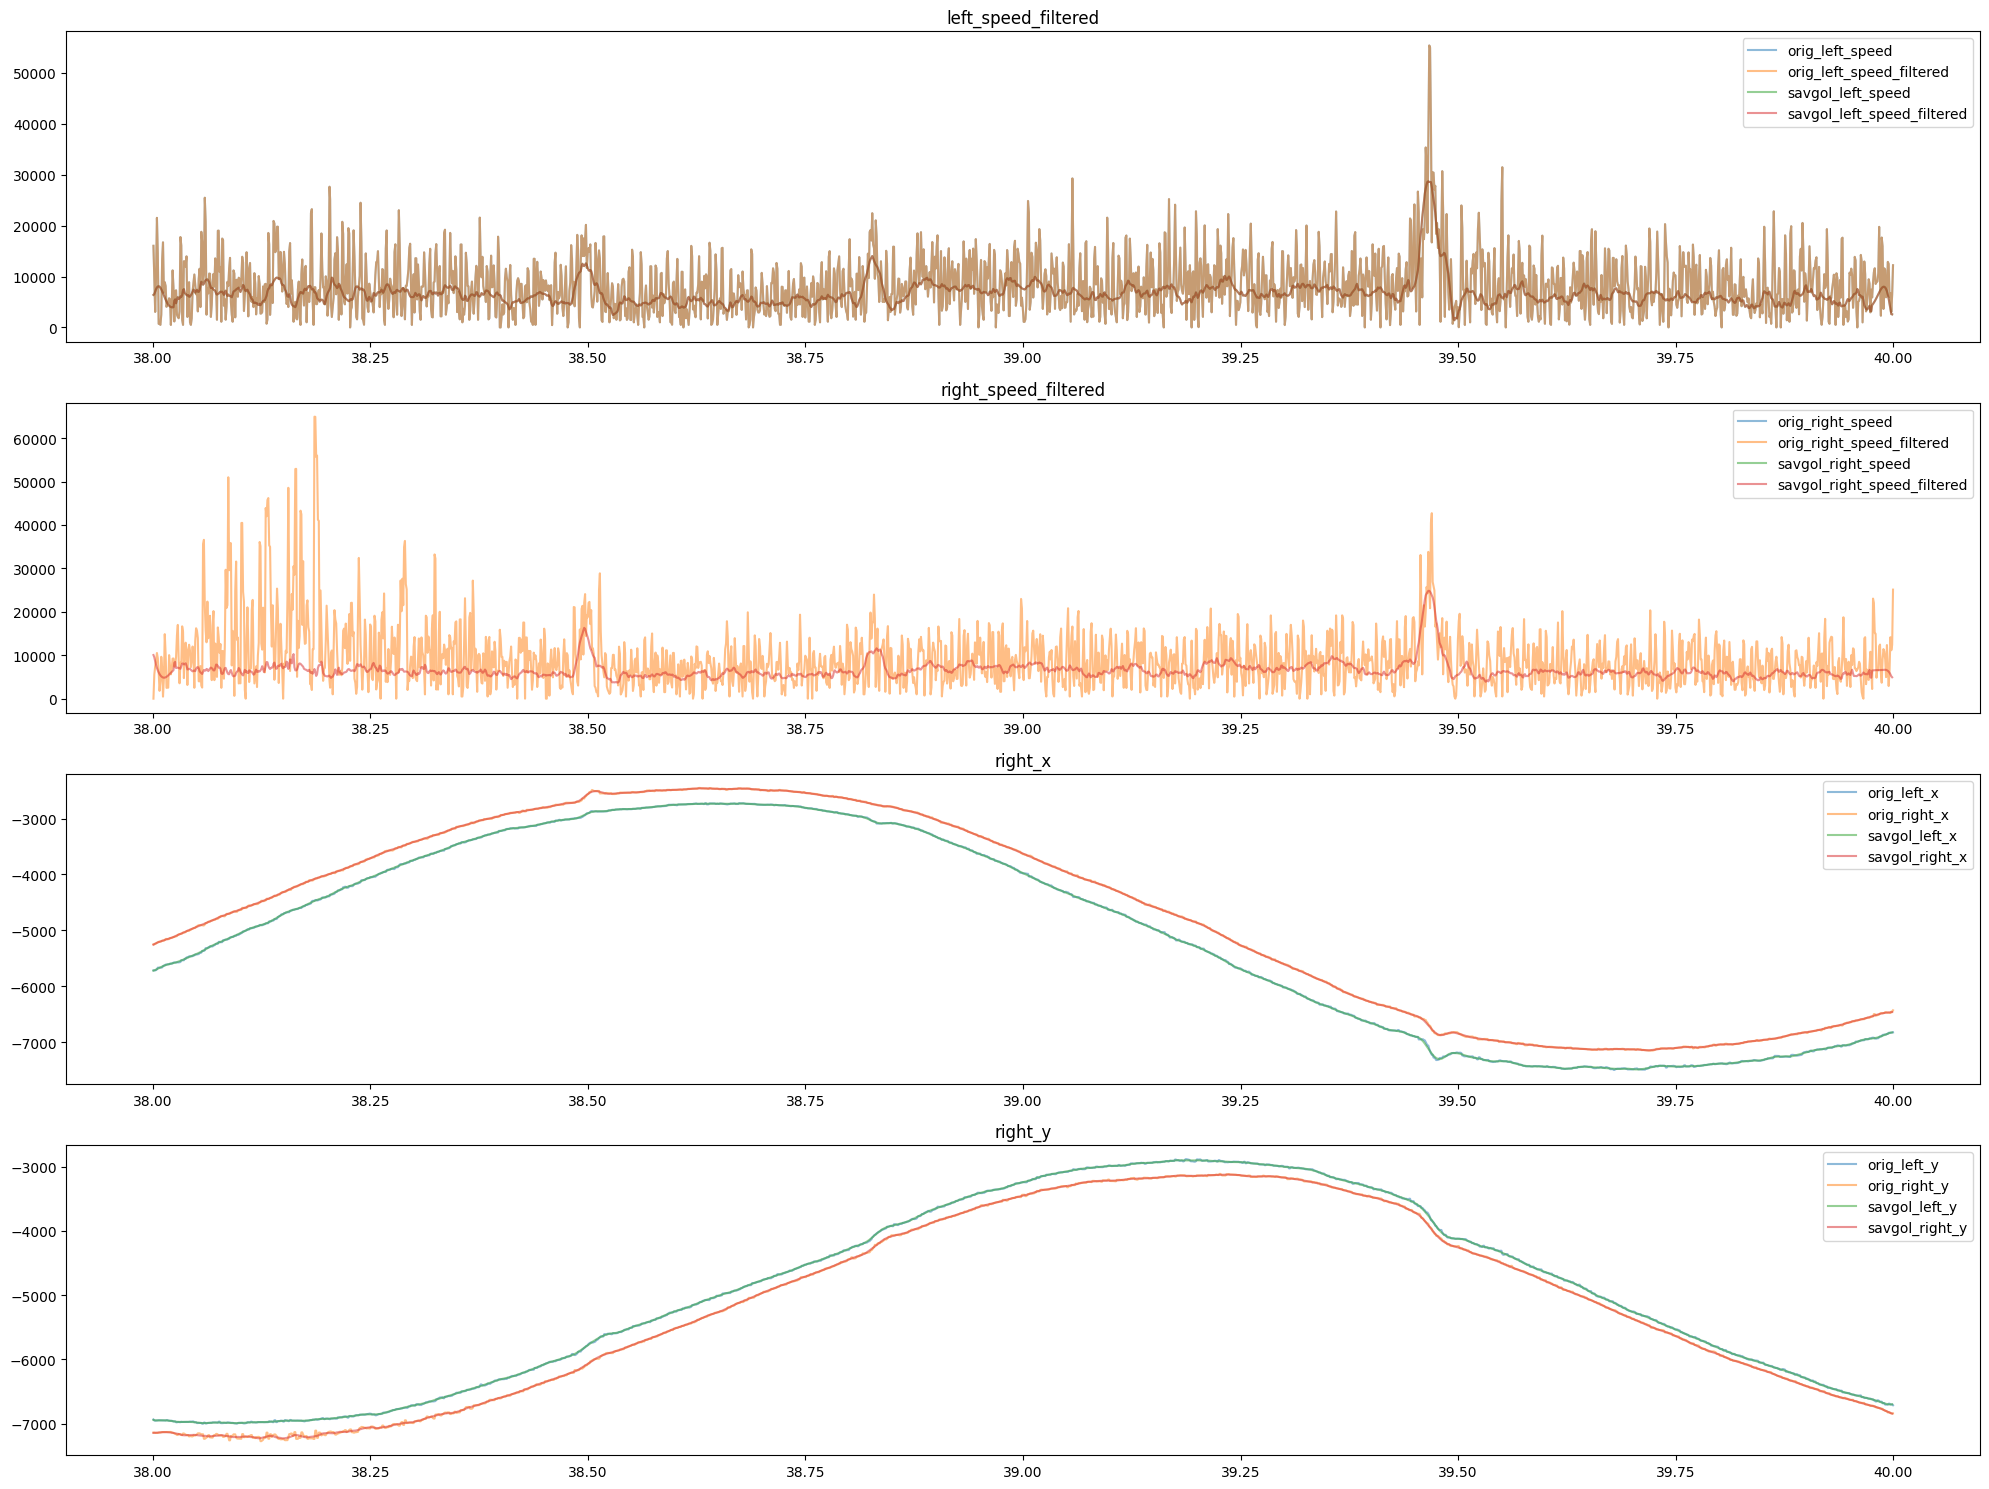

In [7]:
max_speed = 1000000
min_speed = 0
start_time = 38
end_time = 40

orig_df = pd.read_csv(
    os.path.join(session_dir, "raw_eyelink.csv"), index_col=False
)
orig_df = cast(
    pd.DataFrame,
    orig_df[(orig_df["time"] > start_time) & (orig_df["time"] < end_time)],
)

smooth_df = smooth_rolling(
    orig_df,  # type: ignore
    columns=["left_x", "left_y", "right_x", "right_y"],
    on="time",
    freq=eyelink_freq,
    window=0.01,
    on_unit="s",
)
savgol_df = smooth_savgol(
    orig_df,  # type: ignore
    columns=["left_x", "left_y", "right_x", "right_y"],
    freq=eyelink_freq,
    on="time",
    window=0.05,
    polyorder=5,
    reindex_tolerance=3 / eyelink_freq,
)

dfs = {"orig": orig_df, "smooth": smooth_df, "savgol": savgol_df}
for name, df in dfs.items():
    for eye in ["left", "right"]:
        # Calculate speed
        dfs[name] = calculate_eyelink_speed(dfs[name])
        df = dfs[name]
        col = df[f"{eye}_speed"]

        # Filter out samples with speed > max_speed or < min_speed
        above_max_speed = col > max_speed
        below_min_speed = col < min_speed
        filtered_mask = above_max_speed | below_min_speed
        assert (
            filtered_mask.sum()
            == above_max_speed.sum() + below_min_speed.sum()
        )
        filtered_col = col.copy()
        filtered_col[filtered_mask] = np.nan
        col[~filtered_mask] = np.nan

        df[f"{eye}_speed"] = col
        df[f"{eye}_speed_filtered"] = filtered_col

        print(
            f"Found {above_max_speed.sum()} samples above {max_speed} and {below_min_speed.sum()} "
            f"samples below {min_speed} out of {len(col)} sample for {name}_df[{eye}_speed]"
        )

# del dfs["orig"]
del dfs["smooth"]
# del dfs["savgol"]
columns = []
columns.extend(
    [
        ["left_speed", "left_speed_filtered"],
        ["right_speed", "right_speed_filtered"],
    ]
)
columns.extend([("left_x", "right_x"), ("left_y", "right_y")])
fig, axs = plt.subplots(len(columns), 1, figsize=(20, 15))
for name, df in dfs.items():
    for i, cols in enumerate(columns):
        for col in cols:
            tmp_col = df[col]
            # tmp_col[tmp_col > 30000] = np.nan
            axs[i].plot(
                df["time"],
                tmp_col,
                ls="-",
                alpha=1 / len(dfs),
                label=f"{name}_{col}",
            )
        axs[i].set_title(col)
        axs[i].legend()
plt.tight_layout()

In [4]:
df[df["left_speed"] <= 0]

,time,left_x,left_y,right_x,right_y,left_pupil,right_pupil,left_speed,left_speed_filtered,right_speed,right_speed_filtered


In [5]:
eyelink_df, markers_df = format_timestamps(
    eyelink_df, markers_df, eyelink_freq, markers_freq
)

NameError: name 'format_timestamps' is not defined

In [ ]:
eyelink_df, markers_df = clean_data(eyelink_df, markers_df, marker_idx=0)
df = merge_eyelink_markers(eyelink_df, markers_df)
df = interpolate_markers(df)

In [ ]:
df

In [ ]:
plot_eyelink_markers(df, df)

In [ ]:
arr = df[["left_x", "left_y", "right_x", "right_y"]].values
arr = arr.reshape(arr.shape[0], 2, 2)

In [ ]:
animate_2d_dots(arr, 1000, save_path="eyelink.mp4")

In [ ]:
arr = df[["marker_x", "marker_y", "marker_z"]].values
arr = arr.reshape(arr.shape[0], 1, 3)

In [ ]:
animate_3d_dots(arr, 1000, save_path="markers.mp4")